In [1]:
!pip install -q datasets[audio] librosa soundfile matplotlib numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.3 MB/s eta 0:00:00


In [2]:
import os, json, random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from datasets import load_dataset, Audio, Dataset
import librosa, librosa.display
import soundfile as sf

import warnings; warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

## Задание 1. Выбор и загрузка датасета(ов)

In [3]:
def load_local(dataset_path, config, split):
    # dataset_path/
    #   en-AU/
    #     train/
    #       audio_files.wav
    #       metadata.csv

    audio_paths = []
    audio_arrays = []
    sampling_rates = []

    target_dir = os.path.join(dataset_path, config, split)

    if not os.path.exists(target_dir):
        raise FileNotFoundError(f"{target_dir} not found")

    audio_extensions = ['.wav', '.mp3', '.flac', '.m4a']

    for file in os.listdir(target_dir):
        if any(file.lower().endswith(ext) for ext in audio_extensions):
            audio_path = os.path.join(target_dir, file)
            audio_paths.append(audio_path)

            try:
                audio_array, sampling_rate = librosa.load(audio_path, sr=None)
                audio_arrays.append(audio_array)
                sampling_rates.append(sampling_rate)
            except Exception as e:
                print(f"Error in loading {audio_path}: {e}")
                audio_arrays.append(None)
                sampling_rates.append(None)

    if not audio_paths:
        raise ValueError(f"No audio in {target_dir}")

    data_dict = {
        'path': audio_paths,
        'audio': [{'array': arr, 'sampling_rate': sr}
                 for arr, sr in zip(audio_arrays, sampling_rates)]
    }

    dataset = Dataset.from_dict(data_dict)
    dataset = dataset.cast_column('audio', Audio())
    return dataset

In [4]:
DATASET_ID = "PolyAI/minds14"
DATASET_CONFIG = "en-AU"        # например: en-AU, ru-RU и т.д. (или None)
DATASET_SPLIT = "train"         # можно взять 'train[:200]' для подвыборки

# загрузка через Datasets
try:
    ds = load_dataset(DATASET_ID, name=DATASET_CONFIG, split=DATASET_SPLIT)
except Exception as e:
    print("Error in load_dataset:", e)
    # локальная загрузка
    # https://huggingface.co/datasets/PolyAI/minds14
    try:
        LOCAL_DATASET_PATH = "/content/AudioML/1"

        ds = load_local(
            dataset_path=LOCAL_DATASET_PATH,
            config=DATASET_CONFIG,
            split=DATASET_SPLIT
        )
        print(f"Successful: {len(ds)} примеров")

    except Exception as local_e:
        print("Failed: ", local_e)
        ds = None

README.md: 0.00B [00:00, ?B/s]

en-AU/train-00000-of-00001.parquet:   0%|          | 0.00/37.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/654 [00:00<?, ? examples/s]

In [5]:
def preview(ds, n=1):
    if ds is None:
        print("Dataset is None")
        return

    # print(ds.features)
    for feature_name, feature_type in ds.features.items():
        print(f"{feature_name}: {feature_type}")

    print(f"\nПРИМЕР")
    for i in range(n):
      example = ds[i]
      for key, value in example.items():
          if key == 'audio' and isinstance(value, dict):
              print(f"{key}:")
              print(f"  array: форма {value['array'].shape}, тип {value['array'].dtype}")
              print(f"  sampling_rate: {value['sampling_rate']}")
          else:
              print(f"{key}: {value}")

preview(ds, n=1)

path: Value('string')
audio: Audio(sampling_rate=8000, decode=True, stream_index=None)
transcription: Value('string')
english_transcription: Value('string')
intent_class: ClassLabel(names=['abroad', 'address', 'app_error', 'atm_limit', 'balance', 'business_loan', 'card_issues', 'cash_deposit', 'direct_debit', 'freeze', 'high_value_payment', 'joint_account', 'latest_transactions', 'pay_bill'])
lang_id: ClassLabel(names=['cs-CZ', 'de-DE', 'en-AU', 'en-GB', 'en-US', 'es-ES', 'fr-FR', 'it-IT', 'ko-KR', 'nl-NL', 'pl-PL', 'pt-PT', 'ru-RU', 'zh-CN'])

ПРИМЕР
path: en-AU~PAY_BILL/response_4.wav
audio: <datasets.features._torchcodec.AudioDecoder object at 0x7d6c727e0b30>
transcription: I would like to pay my electricity bill using my card can you please assist
english_transcription: I would like to pay my electricity bill using my card can you please assist
intent_class: 13
lang_id: 2


## Задание 2. Базовые характеристики аудиосигнала



In [8]:
# функции вычисления характеристик
def num_channels(arr: np.ndarray) -> int:
    """Возвращает количество каналов (1 для моно)."""
    if arr.ndim == 1: return 1
    # если стерео (C x T или T x C)
    else:
        # более длинная размерность это временная ось
        if arr.shape[0] > arr.shape[1]:
            return arr.shape[1]  # (T x C)
        else:
            return arr.shape[0]  # (C x T)

def peak_level(arr: np.ndarray) -> float:
    """Пиковый уровень max |x| для float в [-1, 1]."""
    return float(np.max(np.abs(arr)))

def rms_level(arr: np.ndarray) -> float:
    """RMS-уровень сигнала."""
    # Root Mean Square — это усреднённая громкость сигнала в отрывке аудио.
    # Обычно это среднее арифметическое между самым тихим и самым громким участком последней секунды или всего трека
    return float(np.sqrt(np.mean(arr**2)))

def dynamic_range(arr: np.ndarray) -> float:
    """Оценка динамического диапазона (пиковый уровень / RMS уровень)."""
    peak = peak_level(arr)
    rms = rms_level(arr)
    if rms > 0:
        return 20 * np.log10(peak / rms)  # в dB
    else:
        return 0.0

def clipping_ratio(arr: np.ndarray, thr: float = 0.999) -> float:
    """Доля сэмплов близких к клиппингу (|x| >= thr)."""
    # Клиппинг (отсечение, срезание) — это нелинейные искажения звука из-за жёсткого амплитудного ограничения цифрового или аналогового сигнала.
    # Система не может точно воспроизводить форму волны, вместо этого отсекает пики сигнала, в результате чего волна принимает форму, близкую к трапеции
    clipped_samples = np.sum(np.abs(arr) >= thr)
    return float(clipped_samples / len(arr))

def zero_crossing_rate(arr: np.ndarray) -> float:
    """Оценка ZCR (число пересечений нуля / длина)."""
    signs = np.sign(arr)
    zero_crossings = np.sum(np.abs(np.diff(signs))) / 2
    return float(zero_crossings / len(arr))


def spectral_stats(arr: np.ndarray, sr: int):
    """Спектральные признаки: центроид и полоса (bandwidth)."""
    # Спектральный центроид — указывает, на какой частоте сосредоточена энергия спектра, «центр масс» для звука.
    # Bandwidth — диапазон частот, занимаемый сигналом. Измеряется в герцах (Гц) или кратных единицах (кГц, МГц).
    # рост полосы - хорошо, только нужно больше энергии для передачи
    spectral_centroids = librosa.feature.spectral_centroid(y=arr, sr=sr)
    centroid_mean = float(np.mean(spectral_centroids))

    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=arr, sr=sr)
    bandwidth_mean = float(np.mean(spectral_bandwidth))

    return centroid_mean, bandwidth_mean

def duration_seconds(arr: np.ndarray, sr: int) -> float:
    return len(arr) / float(sr)



In [9]:
# сбор метрик
N = 200
metrics = []

if ds is not None:
    idxs = np.random.choice(len(ds), size=min(N, len(ds)), replace=False)
    for i in tqdm(idxs, desc="Computing metrics"):
        ex = ds[int(i)]
        aud = ex.get("audio", {})
        if aud is None: continue
        arr = aud.get("array") if hasattr(aud, 'get') else aud['array']
        sr = aud.get("sampling_rate") if hasattr(aud, 'get') else aud['sampling_rate']
        if arr is None or sr is None:
            continue
        # Если многоканальный — приведите к моно для метрик или учитывайте каналы отдельно
        if num_channels(arr) > 1:
            # Приводим к моно усреднением по каналам
            if arr.ndim == 2:
                if arr.shape[0] > arr.shape[1]:  # (t x c)
                    arr = np.mean(arr, axis=1)
                else:  # (c x t)
                    arr = np.mean(arr, axis=0)
        m = {
            "sr": sr,
            "dur_s": duration_seconds(arr, sr),
            "channels": num_channels(arr),
            "peak": peak_level(arr),
            "rms": rms_level(arr),
            "dynamic_range": dynamic_range(arr),
            "clip_ratio": clipping_ratio(arr),
            "zcr": zero_crossing_rate(arr),
        }
        centroid, bandwidth = spectral_stats(arr, sr)
        m.update({
            "spectral_centroid": centroid,
            "spectral_bandwidth": bandwidth
        })

        metrics.append(m)

metrics[:3]


Computing metrics: 100%|██████████| 200/200 [00:03<00:00, 54.63it/s]


[{'sr': 8000,
  'dur_s': 6.130125,
  'channels': 1,
  'peak': 0.8553466796875,
  'rms': 0.11050475388765335,
  'dynamic_range': np.float64(17.775224243915023),
  'clip_ratio': 0.0,
  'zcr': 0.28288576006889343,
  'spectral_centroid': 1356.011504334573,
  'spectral_bandwidth': 893.6857253217421},
 {'sr': 8000,
  'dur_s': 19.285375,
  'channels': 1,
  'peak': 0.6365966796875,
  'rms': 0.07038895040750504,
  'dynamic_range': np.float64(19.127197595706004),
  'clip_ratio': 0.0,
  'zcr': 0.17708367109298706,
  'spectral_centroid': 903.2753589508214,
  'spectral_bandwidth': 824.9591181041026},
 {'sr': 8000,
  'dur_s': 6.62,
  'channels': 1,
  'peak': 0.3162841796875,
  'rms': 0.024265199899673462,
  'dynamic_range': np.float64(22.301871918343352),
  'clip_ratio': 0.0,
  'zcr': 0.24728097021579742,
  'spectral_centroid': 1352.8467343967257,
  'spectral_bandwidth': 1027.84003577593}]

In [10]:
# сводкa (mean/median/p95)
def agg(values):
    if not values: return {"mean": None, "median": None, "p95": None}
    arr = np.array(values, dtype=float)
    return {"mean": float(np.mean(arr)), "median": float(np.median(arr)), "p95": float(np.percentile(arr, 95))}

def summarize(metrics):
    keys = [k for k in metrics[0].keys() if isinstance(metrics[0][k], (int, float))]
    summary = {}
    for k in keys:
        summary[k] = agg([m[k] for m in metrics if m.get(k) is not None])
    return summary

if metrics:
    summary = summarize(metrics)
    print(json.dumps(summary, indent=2, ensure_ascii=False))
else:
    print("Нет метрик для сводки — проверьте загрузку/вычисления.")


{
  "sr": {
    "mean": 8000.0,
    "median": 8000.0,
    "p95": 8000.0
  },
  "dur_s": {
    "mean": 8.31026875,
    "median": 6.315250000000001,
    "p95": 19.298106249999993
  },
  "channels": {
    "mean": 1.0,
    "median": 1.0,
    "p95": 1.0
  },
  "peak": {
    "mean": 0.589521484375,
    "median": 0.6053466796875,
    "p95": 0.9506591796874995
  },
  "rms": {
    "mean": 0.05825573761947453,
    "median": 0.0539681538939476,
    "p95": 0.11829727888107298
  },
  "dynamic_range": {
    "mean": 20.60062966810209,
    "median": 20.2117843310835,
    "p95": 26.39666151755495
  },
  "clip_ratio": {
    "mean": 0.0,
    "median": 0.0,
    "p95": 0.0
  },
  "zcr": {
    "mean": 0.22277571208775043,
    "median": 0.2212238535284996,
    "p95": 0.2935209572315216
  },
  "spectral_centroid": {
    "mean": 1298.3448414904458,
    "median": 1289.7793218639606,
    "p95": 1635.393062125947
  },
  "spectral_bandwidth": {
    "mean": 955.9951620753569,
    "median": 970.6989892778133,
    "p

## Задание 3. Визуализация: waveform, спектр, Mel/Log‑Mel

In [11]:
def plot_waveform(arr, sr, title="Waveform"):
    plt.figure()
    librosa.display.waveshow(arr, sr=sr)
    plt.title(title); plt.xlabel("Time"); plt.ylabel("Amplitude"); plt.show()

def plot_spectrogram_db(arr, sr, n_fft=2048, hop_length=512, title="Spectrogram (dB)"):
    import numpy as np
    D = librosa.stft(arr, n_fft=n_fft, hop_length=hop_length)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    plt.figure()
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
    plt.title(title); plt.colorbar(); plt.show()

def plot_mel_logmel(arr, sr, n_fft=2048, hop_length=512, n_mels=80, fmax=None, htk=False, title_prefix="Mel"):
    import numpy as np
    mel = librosa.feature.melspectrogram(y=arr, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, fmax=fmax, htk=htk)
    logmel = librosa.power_to_db(mel, ref=np.max)
    plt.figure()
    librosa.display.specshow(logmel, sr=sr, x_axis='time', y_axis='mel', hop_length=hop_length)
    plt.title(f"{title_prefix}: log-Mel (n_mels={n_mels}, htk={htk})"); plt.colorbar(); plt.show()
    return mel, logmel

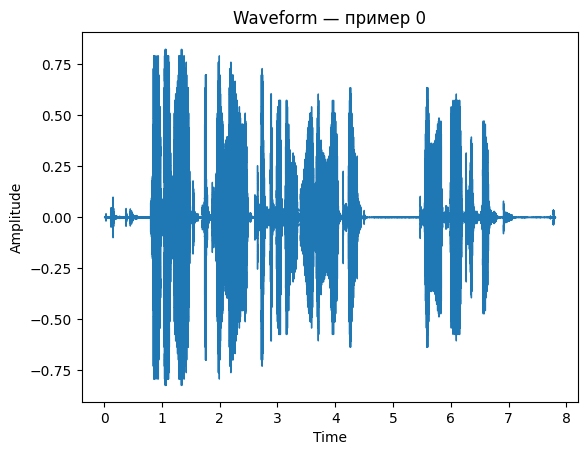

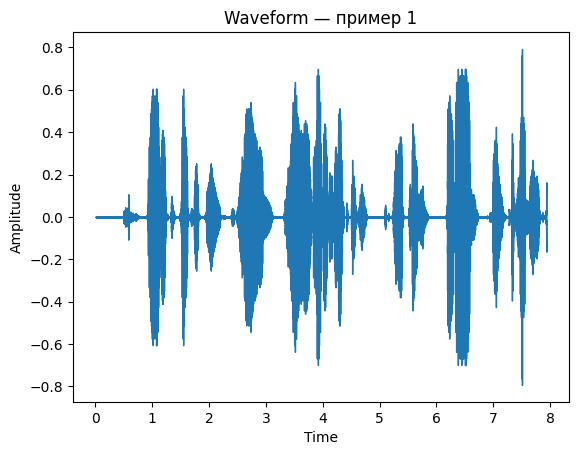

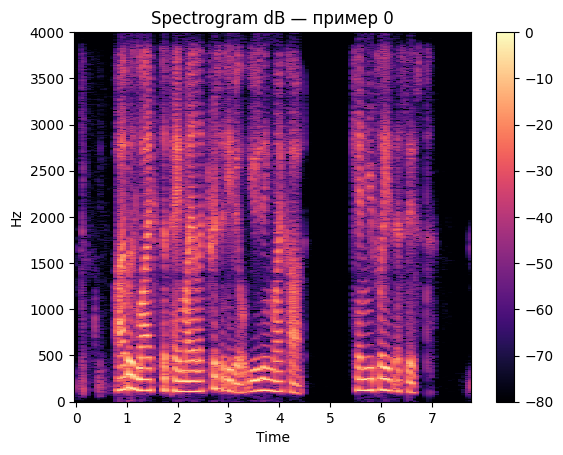

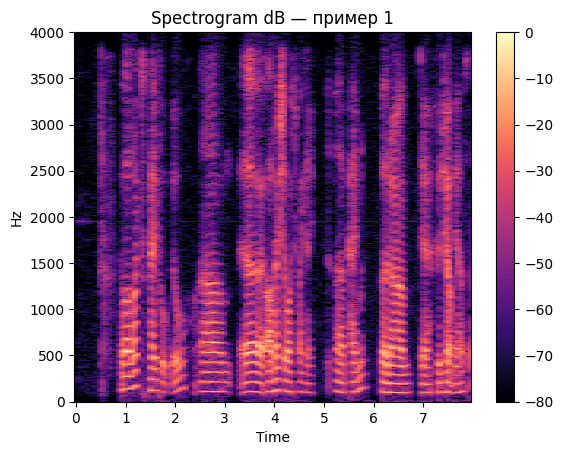

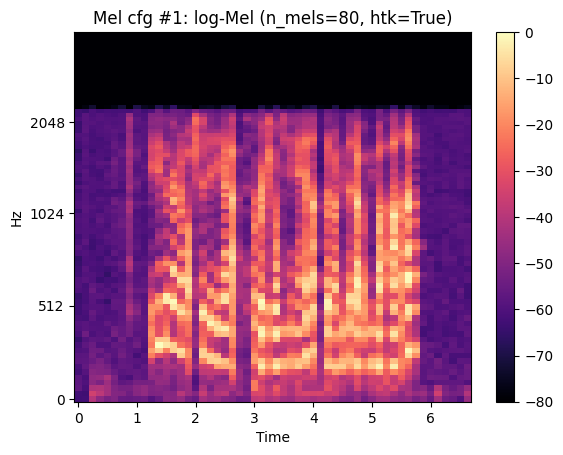

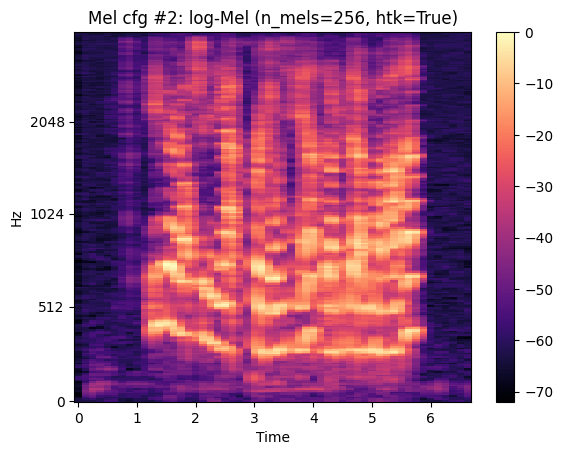

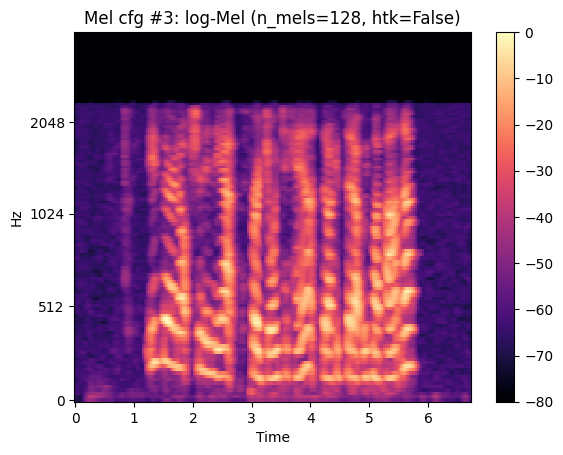

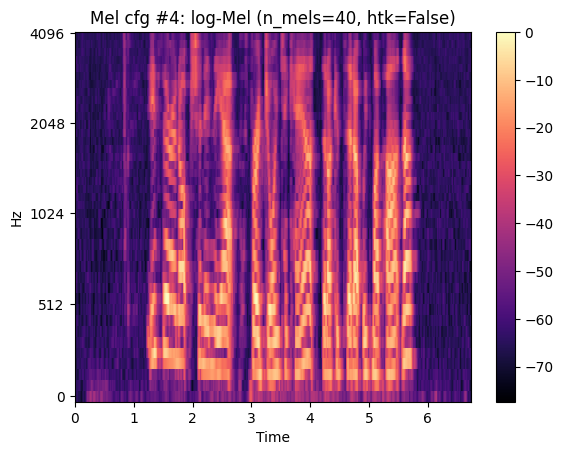

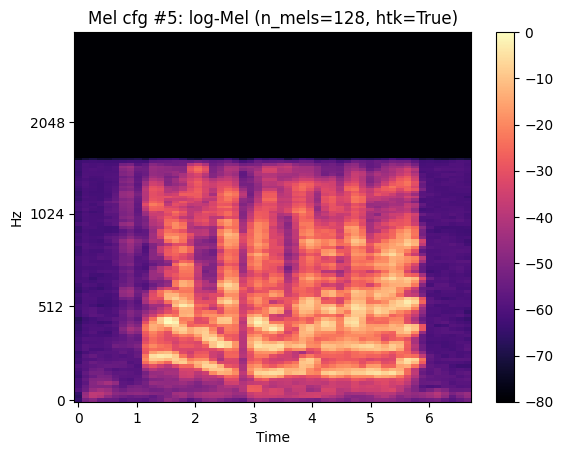

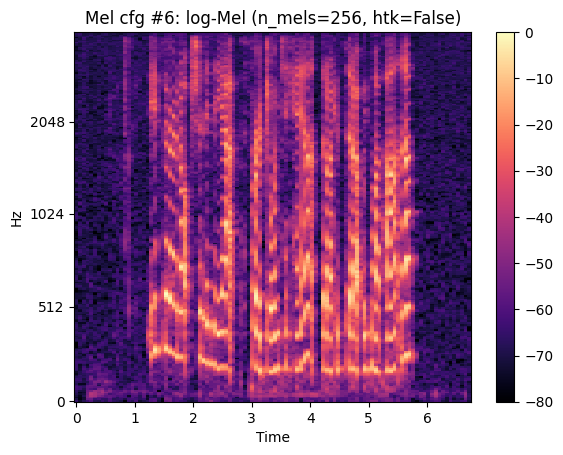

In [12]:
if ds is not None and len(ds) > 0:
    ex0, ex1 = ds[0], ds[1]
    arr0, sr0 = ex0['audio']['array'], ex0['audio']['sampling_rate']
    arr1, sr1 = ex1['audio']['array'], ex1['audio']['sampling_rate']


    plot_waveform(arr0, sr0, title="Waveform — пример 0")
    plot_waveform(arr1, sr1, title="Waveform — пример 1")
    plot_spectrogram_db(arr0, sr0, n_fft=2048, hop_length=512, title="Spectrogram dB — пример 0")
    plot_spectrogram_db(arr1, sr1, n_fft=2048, hop_length=512, title="Spectrogram dB — пример 1")

    # Mel/Log‑Mel: сравнение конфигураций
    cfgs = [
        dict(n_fft=1500, hop_length=1000, n_mels=80, fmax=8000, htk=True),
        dict(n_fft=4096, hop_length=1000, n_mels=256, fmax=None, htk=True),
        dict(n_fft=2048, hop_length=256, n_mels=128, fmax=8000, htk=False),
        dict(n_fft=512, hop_length=128, n_mels=40, fmax=4000, htk=False),
        dict(n_fft=4096, hop_length=1024, n_mels=128, fmax=16000, htk=True),
        dict(n_fft=1024, hop_length=512, n_mels=256, fmax=None, htk=False),
    ]

    for i, cfg in enumerate(cfgs):
        plot_mel_logmel(arr, sr, **cfg, title_prefix=f"Mel cfg #{i+1}")
else:
    print("Датасет пуст или не загружен.")


mel-спектрограмма. разновидность, которая показывает частотное содержание сигнала, но уже на другой частотной оси из-за mel-фильтров, которые применяются ко всему аудио


Mel‑спектрограммa и Log‑Mel при разных параметрах (`n_fft`, `hop_length`, `n_mels`, `fmax`, `htk/slaney`).
Сравнить конфигурации и описать наблюдения.

1. набор параметров под речь
2. набор параметров под музыку, менее удобное представление, все размыто
3. средние параметры, но меньше шаг между окнами по сравнению с предыдущими. видно что по OX более плавно!
4. Высокое временное разрешение
5. Высокое частотное разрешение
6. поставили много мел-фильтров, видим что информация по частотам более детальная.



Параметры:

n_fft - размер окна для FFT
=====
длина окна FFT в аудиосигналах — это параметр, который указывает на число анализируемых отсчётов сигнала.
unisonrecords.ru
FFT (fast Fourier transform) — алгоритм быстрого вычисления дискретного преобразования Фурье, который позволяет анализировать спектр звуковых сигналов в реальном времени

Больше: лучше частотное разрешение, хуже временное

Меньше: лучше временное разрешение, хуже частотное


hop_length - шаг между окнами
=====
количество выборок между последовательными кадрами. Например, если есть 1000 аудиосэмплов, а hop_length равен 100, то получится 10 кадров функций

Меньше: плавнее по времени, больше вычислений

Больше: грубее по времени, меньше вычислений

n_mels - количество мел-фильтров
=====
количество генерируемых мел-диапазонов. Мел-диапазоны определяют набор частотных диапазонов, которые разделяют спектр на перцептивно значимые компоненты.

Больше: детальнее частотная информация, больше размерность

Меньше: компактнее, хуже различение частот

fmax - максимальная частота
=====
по умолчанию используется значение fmax = sr / 2,0
+ Ниже: фокус на низких частотах (речь)

+ Выше: захват высоких гармоник

+ None: полный диапазон (sr/2)

htk - тип мел-шкалы
=====
False (Slaney): стандартная психоакустическая шкала

True: альтернативная реализация HTK

///
- Речь: n_fft=1024-2048, n_mels=40-80, fmax=8000

- Музыка: n_fft=2048-4096, n_mels=128-256, fmax=None

## Задание 4. Передискретизация и сравнение (resampling)
**Что сделать:**
1. Передискретизировать сигнал до 16 kHz (если исходно другой SR) и сравнить waveform/спектры до/после.
2. Посчитать Nyquist‑частоту для обеих SR и обсудить, какие частоты потенциально теряются.
3. Оценить влияние `hop_length` при фиксированном `n_fft` на временное/частотное разрешение.

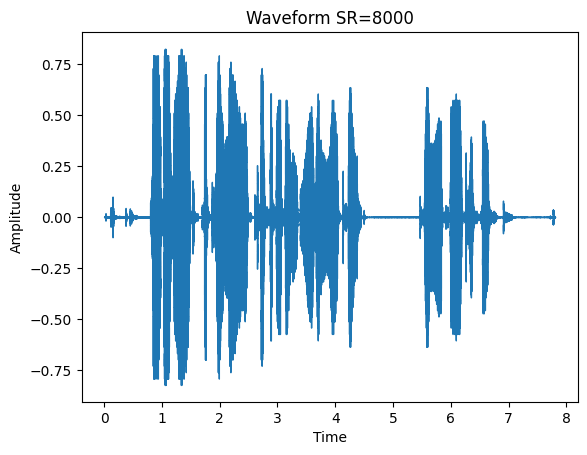

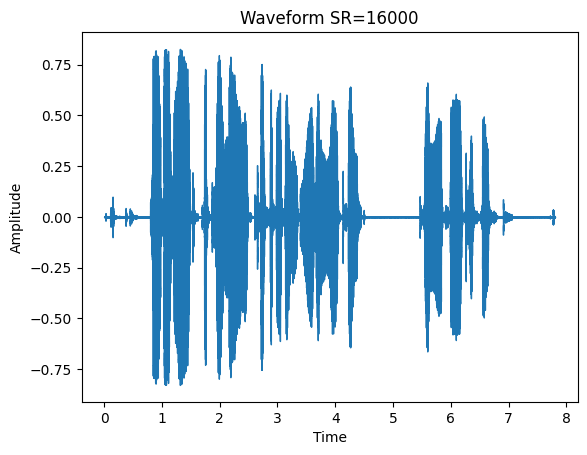

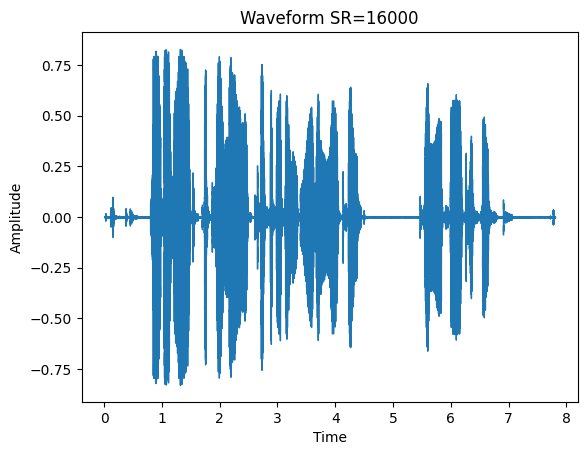

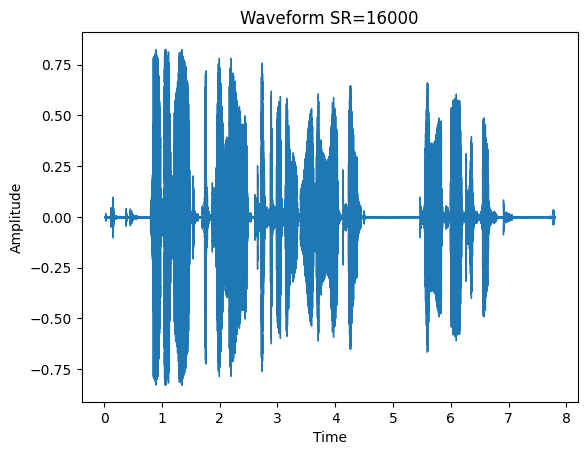

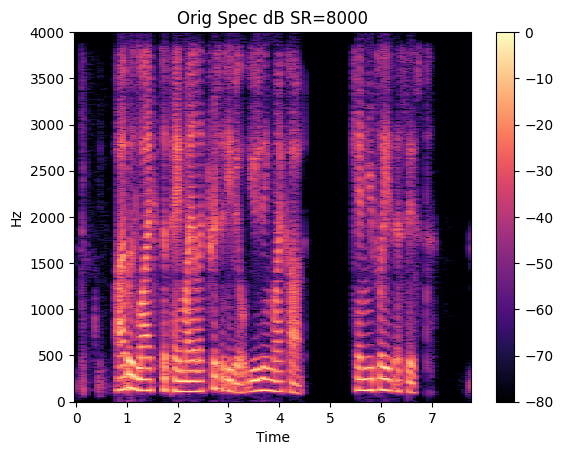

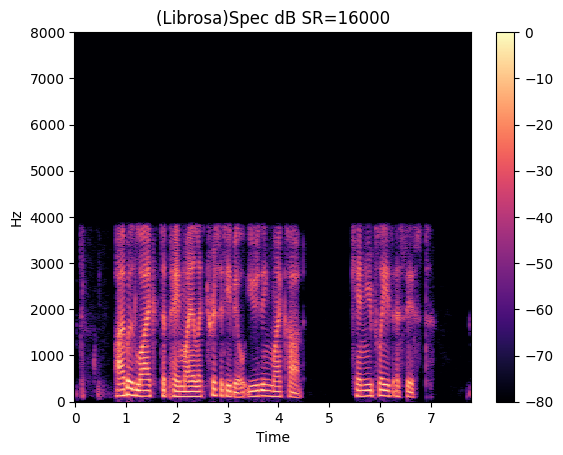

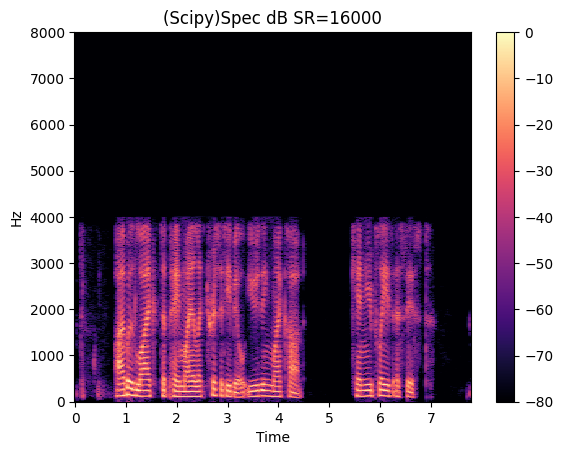

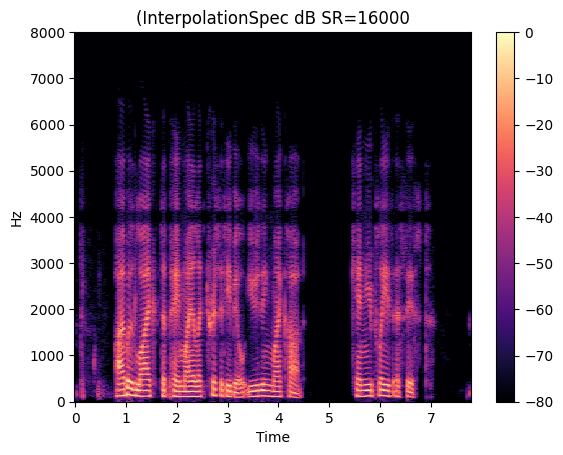

Nyquist исходный: 4000.0 Hz; после: 8000.0 Hz


In [23]:

# TODO-4.1: ресемплинг и сравнение
from IPython.display import Audio, display
from scipy import signal, interpolate
TARGET_SR = 16_000

def resample(arr, sr, target_sr=TARGET_SR):
    if sr == target_sr:
        return arr, sr
    resampled = librosa.resample(arr, orig_sr=sr, target_sr=target_sr)
    return resampled, target_sr

def resample_scipy(arr, sr, target_sr=TARGET_SR):
    if sr == target_sr:
        return arr, sr
    num_samples = int(len(arr) * target_sr / sr)
    resampled = signal.resample(arr, num_samples)
    return resampled, target_sr

def resample_interpolation(arr, sr, target_sr=TARGET_SR):
    if sr == target_sr:
        return arr, sr
    # временные оси
    time_orig = np.linspace(0, len(arr)/sr, len(arr))
    time_new = np.linspace(0, len(arr)/sr, int(len(arr) * target_sr / sr))
    # кубическая интерполяция
    interpolator = interpolate.interp1d(time_orig, arr, kind='cubic', fill_value='extrapolate')
    resampled = interpolator(time_new)
    return resampled, target_sr

def nyquist(sr):
    return sr / 2.0

if ds is not None and len(ds) > 0:
    ex = ds[0]
    arr, sr = ex['audio']['array'], ex['audio']['sampling_rate']
    arr2, sr2 = resample(arr, sr, TARGET_SR)
    arr_s, sr_s = resample_scipy(arr, sr, TARGET_SR)
    arr_int, sr_int = resample_interpolation(arr, sr, TARGET_SR)
    # Аудио сравнение
    display(Audio(data=arr, rate=sr))
    display(Audio(data=arr2, rate=sr2))
    # Визуальное сравнение
    plot_waveform(arr, sr, title=f"Waveform SR={sr}")
    plot_waveform(arr2, sr2, title=f"Waveform SR={sr2}")
    plot_waveform(arr_s, sr_s, title=f"Waveform SR={sr_s}")
    plot_waveform(arr_int, sr_int, title=f"Waveform SR={sr_int}")
    plot_spectrogram_db(arr, sr, title=f"Orig Spec dB SR={sr}")
    plot_spectrogram_db(arr2, sr2, title=f"(Librosa)Spec dB SR={sr2}")
    plot_spectrogram_db(arr_s, sr_s, title=f"(Scipy)Spec dB SR={sr_s}")
    plot_spectrogram_db(arr_int, sr_int, title=f"(InterpolationSpec dB SR={sr_int}")
    print("Nyquist исходный:", nyquist(sr), "Hz; после:", nyquist(sr2), "Hz")
    # print(f"\nДлительность до: {len(arr)/sr:.3f} сек")
    # print(f"Длительность после: {len(arr2)/sr2:.3f} сек")
else:
    print("Датасет пуст или не загружен.")


Анализ:
Потери частот при ресемплинге:
===
Исходный Nyquist: sr/2 Hz (8000 Hz при sr=16000)

Целевой Nyquist: 16000/2 = 8000 Hz

Какие частоты теряются: Все частоты выше целевого Nyquist (8000 Hz) будут отфильтрованы антиалиасинговым фильтром

librosa: фильтр низких частот, который обрезает все частоты выше новой частоты Найквиста (SR/2) перед ресемплингом. Сначала применяет ФНЧ с частотой среза ~8000 Hz. Потом уменьшает частоту дискретизации и убирает высокие частоты, которые не могут быть представлены в новом SR

!! метод с интерполяцией не боролся с алиасингом

Влияние hop_length при фиксированном n_fft:
===
Временное разрешение:

Меньший hop_length: Выше временное разрешение => лучше видно быстрые изменения сигнала

Больший hop_length: Ниже временное разрешение => сглаживание по времени

Частотное разрешение:

hop_length не влияет на частотное разрешение, только на временное

( так как только n_fft (Δf = sr/n_fft) )

hop_length = n_fft/4: хороший баланс между разрешениями



Артефакты - Нежелательные искажения сигнала, которых не было в оригинале.
===
Алиасинг (Aliasing):

высокочастотный звук превращается в низкочастотный
Исходный: 9000 Hz при SR=22050
После ресемплинга до SR=16000: может появиться 2000 Hz
Временные искажения:

Фазовые сдвиги:
"Дрожание" transient-ов (резких переходов)

Спектральные искажения:
Появление гармоник, которых не было

Изменение тембра голоса/инструментов

## Задание 5. Dataset‑level EDA

**Что сделать:**
1. Построить распределения длительностей, SR, пиковых уровней (гистограммы).
2. (Если есть метки классов) — подсчитать число примеров по классам.
3. Сформировать короткие выводы о качестве сырого датасета (наличие очень коротких/длинных записей, клиппинг и пр.).

(Exploratory Data Analysis) - это анализ на уровне всего датасета, который включает:

Статистическое исследование распределений ключевых характеристик

Выявление аномалий и выбросов в данных

Понимание общей структуры и качества датасета

Принятие решений о предобработке и очистке данных


ДЛИТЕЛЬНОСТИ ЗАПИСЕЙ:
Мин: 1.95 сек, Макс: 30.63 сек
Медиана: 6.32 сек
Записи <0.5 сек: 0 файлов
Записи >10 сек: 51 файлов


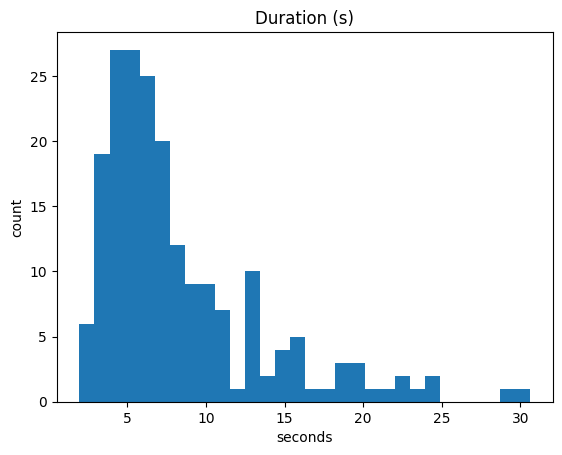

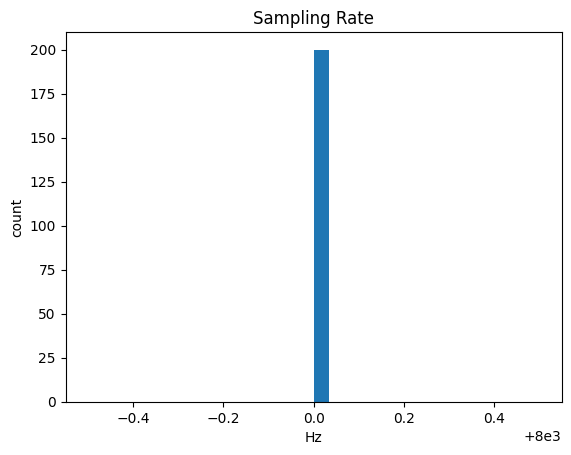

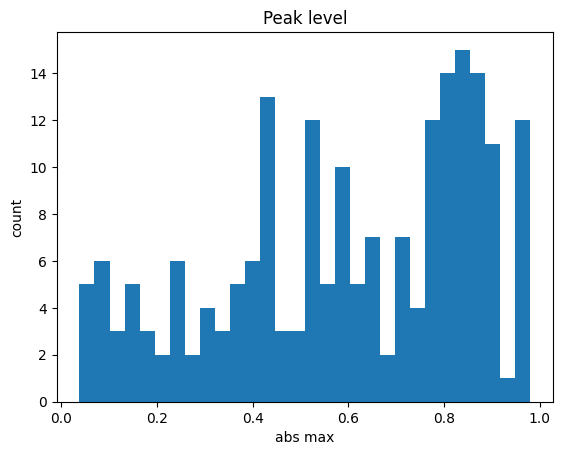

In [26]:

# TODO-5.1: гистограммы и распределения
def hist(values, bins=30, title="Histogram", xlabel="value"):
    import matplotlib.pyplot as plt
    plt.figure()
    plt.hist(values, bins=bins)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel("count"); plt.show()

durs = [m['dur_s'] for m in metrics if m.get('dur_s') is not None]

print("\nДЛИТЕЛЬНОСТИ ЗАПИСЕЙ:")
print(f"Мин: {min(durs):.2f} сек, Макс: {max(durs):.2f} сек")
print(f"Медиана: {np.median(durs):.2f} сек")
print(f"Записи <0.5 сек: {sum(d < 0.5 for d in durs)} файлов")
print(f"Записи >10 сек: {sum(d > 10 for d in durs)} файлов")
if metrics:
    hist([m['dur_s'] for m in metrics if m.get('dur_s') is not None], title="Duration (s)", xlabel="seconds")
    hist([m['sr'] for m in metrics if m.get('sr') is not None], title="Sampling Rate", xlabel="Hz")
    hist([m['peak'] for m in metrics if m.get('peak') is not None], title="Peak level", xlabel="abs max")


# Что имеем

Единая частота дискретизации

Длительности в норме - нет очень коротких и очень длинных

Низкий уровень клиппинга - обрезанных по частотам нет

Уровни громкости можно выровнять - нужна нормализация.
Есть тихие (peak < 0.1)